In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

In [ ]:
df = pd.read_csv("/content/BASETC_MXN_USD (3).csv",
                 skiprows=18,
                 encoding = "latin1",
    )
df.tail()


# le pusimos skiprows 18 por que no nos sirven los titulos de esto


## El latin 1 es para que pueda leer la base de datos, banxico utiliza otro tipo de lenguaje, latin1 para leer este tipo de archivos
## Le estamos poniendo inicio y fin a los datos desde de acuerdo a las instrucciones del primero de enero del 2016 al 31 de diciembre del 2024

,Fecha,SF63528
17783,19/04/2024,17.2120
17784,22/04/2024,17.1243
17785,23/04/2024,16.9995
17786,24/04/2024,17.1098
17787,25/04/2024,17.1883


In [ ]:
# Renombrar la variable SF64528 como precio de venta y fecha en DATE

df.columns = ['Date', 'Close']
df.head()

,Date,Close
0,19/04/1954,0.0125
1,20/04/1954,0.0125
2,21/04/1954,0.0125
3,22/04/1954,0.0125
4,23/04/1954,0.0125


In [ ]:
# Recortar la base de datos

df['Date'] = pd.to_datetime(df['Date'], format='%d/%m/%Y') # el format es para decirle en que orden viene la base de datos, dia - mes - año
df = df[df['Date'] >= '2016-01-01'].reset_index(drop=True) #aqui le decimos que ponga todos desde el primero de enero 2016 hasta ahoirta como dicen las instrucciones


#ojo empieza el 4 de enero por dia festivo y fin de semana

df.tail()

,Date,Close
2087,2024-04-19,17.2120
2088,2024-04-22,17.1243
2089,2024-04-23,16.9995
2090,2024-04-24,17.1098
2091,2024-04-25,17.1883


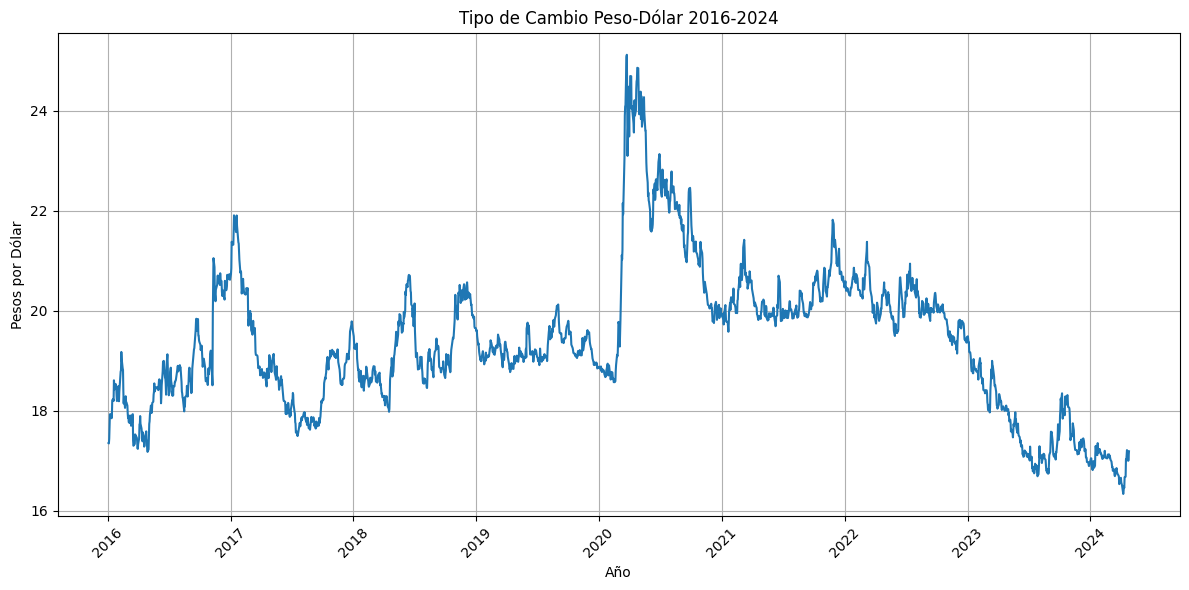

In [ ]:


close = df['Close']

plt.figure(figsize=(12,6))
plt.plot(df['Date'], close)
plt.title("Tipo de Cambio Peso-Dólar 2016-2024")
plt.xlabel("Año")
plt.ylabel("Pesos por Dólar")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()





# Aqui podemos visualizar la base de datos con un pico plaro en el año 2020 donde el dolar se disparo de poco mas de 19 pesos a 25
# asi mismo a finales del año 2016 (aprox noviembre donde entro trump a la presidencia tambien se puede apreciar un pico )
# En noviembre del 2022 (alrededor de esas fechas) se puede apreciar un declive en el costo del dolar probablemente debido a la crisis inflacionaria

In [ ]:
# Definir close2 con frecuencia de días hábiles
close2 = df.set_index('Date')['Close']
close2 = close2.asfreq('B')
close2 = close2.fillna(method='ffill')

/tmp/ipykernel_13673/2762076624.py:4: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  close2 = close2.fillna(method='ffill')


In [ ]:
df.describe() # metricas basicas de la base de datos

# se puede ver que el promedio del dolar en estas fechas es de 19.37 pesos
# asi mismo su mediana de igual manera es de 19.22 pesos
# asi mismo lo mas bajo que ha estado el dolar ha sido en 16.33 pesos y su maximo es de 25.11 pesos

,Date,Close
count,2092,2092.000000
mean,2020-02-27 19:01:15.717017088,19.371948
min,2016-01-04 00:00:00,16.335700
25%,2018-01-29 18:00:00,18.495825
50%,2020-02-29 12:00:00,19.223450
75%,2022-03-28 06:00:00,20.165300
max,2024-04-25 00:00:00,25.118500
std,NaN,1.455017


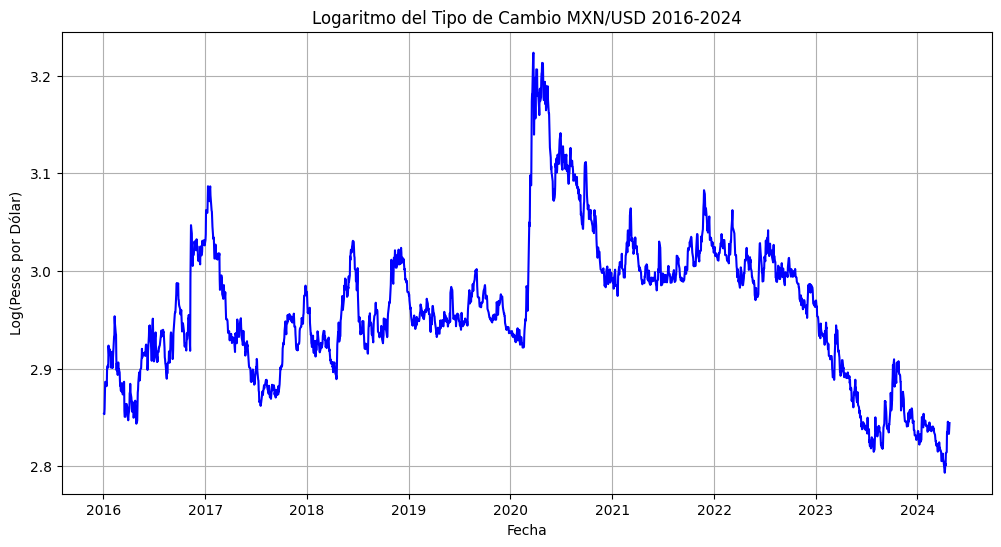

In [ ]:
log_close = np.log(close2)

plt.figure(figsize=(12,6))
plt.plot(log_close.index, log_close.values, color='blue')
plt.title('Logaritmo del Tipo de Cambio MXN/USD 2016-2024')
plt.xlabel('Fecha')
plt.ylabel('Log(Pesos por Dólar)')
plt.grid(True)
plt.show()



#El logaritmo natural de la serie del tipo de cambio MXN/USD permite estabilizar
#la varianza y facilita la identificación visual de la tendencia sin que los choques
#extremos distorsionen la escala. Los valores oscilan entre 2.80 y 3.22 log(pesos
#por dólar). Se identifican claramente dos eventos de alta volatilidad: el alza de
#noviembre de 2016 asociada a la elección de Donald Trump (~3.09) y el pico máximo
#de marzo de 2020 durante la pandemia de COVID-19 (~3.22). A partir de 2023 se
#observa una tendencia a la baja sostenida, reflejando la apreciación del peso
#mexicano frente al dólar.

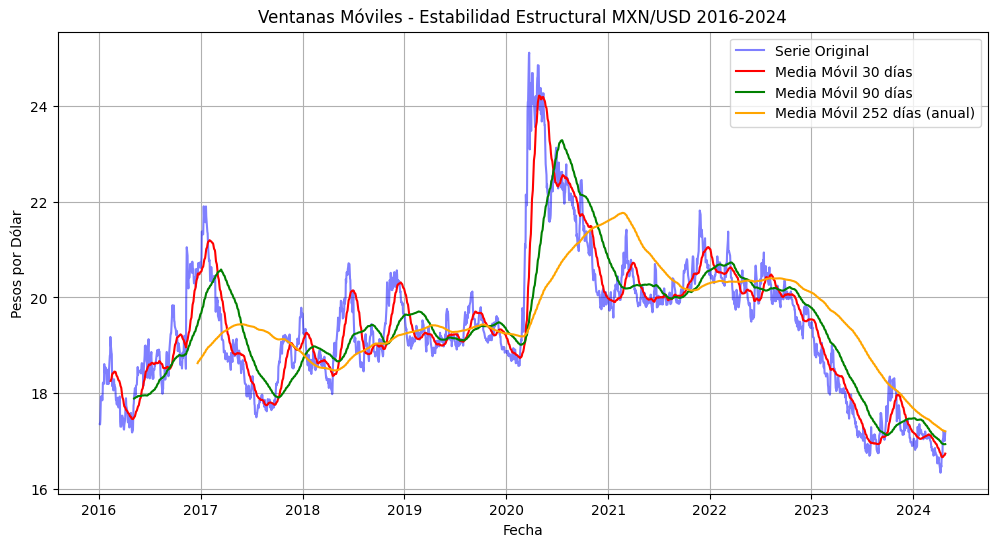

In [ ]:
rolling_mean_30 = close2.rolling(window=30).mean()
rolling_mean_90 = close2.rolling(window=90).mean()
rolling_mean_252 = close2.rolling(window=252).mean()

plt.figure(figsize=(12,6))
plt.plot(close2.index, close2.values, color='blue', alpha=0.5, label='Serie Original')
plt.plot(rolling_mean_30.index, rolling_mean_30.values, color='red', label='Media Móvil 30 días')
plt.plot(rolling_mean_90.index, rolling_mean_90.values, color='green', label='Media Móvil 90 días')
plt.plot(rolling_mean_252.index, rolling_mean_252.values, color='orange', label='Media Móvil 252 días (anual)')
plt.title('Ventanas Móviles - Estabilidad Estructural MXN/USD 2016-2024')
plt.xlabel('Fecha')
plt.ylabel('Pesos por Dólar')
plt.legend()
plt.grid(True)
plt.show()









#Las ventanas móviles (rolling means) calculadas a 30, 90 y 252 días hábiles
#permiten evaluar la estabilidad estructural de la serie del tipo de cambio
#MXN/USD. La media móvil de 30 días (roja) reacciona rápidamente a los choques,
#siguiendo de cerca la serie original. La de 90 días (verde) suaviza las
#fluctuaciones de corto plazo mostrando tendencias trimestrales. La de 252 días
#(naranja) captura únicamente el movimiento de largo plazo anual.

#Se identifican claramente dos quiebres estructurales: el pico de 2017 asociado
#a la elección de Donald Trump en noviembre de 2016, y el spike máximo de 2020
#provocado por la pandemia de COVID-19, donde el tipo de cambio llegó a 25 pesos
#por dólar. A partir de 2023 las tres medias muestran una caída sostenida,
#reflejando la apreciación significativa del peso mexicano. El hecho de que
#ninguna de las tres medias se estabilice en un valor constante confirma la
#no estacionariedad de la serie, consistente con los resultados del test ADF.



In [ ]:
# Test de estacionariedad

test = adfuller(close.dropna())
print('ADF: %f' % test[0])
print('P-Value ADF: %f'% test[1])


ADF: -2.669359
P-Value ADF: 0.079492


In [ ]:
# P-Value ADF = 0.079492 >0.05
# eso nos indica que la serie es No estacionaria por lo que no se rechaza la hipotesis nula
# HO: Serie no estacionaria esto nos indica que en efecta la serie tiene una tendencia



# Una serie con tendencia es impredecible por lo que se encesita quitar la tendencia a la serie sin eiliminar ni quitar datos
# Se necesita ESTACIONAR LA SERIE


### entre mas estacionaria la serie es mejor  el adf tambien es un indicador pero normalmente tiene que ser menor a -5 para que se considere estacionaria


In [ ]:
#Phillips-Perron Test


!pip install arch -q

from arch.unitroot import PhillipsPerron

pp = PhillipsPerron(close2.dropna())
print(pp.summary())



#La prueba de Phillips-Perron arrojó un p-value de 0.060, resultado
#borderline que al nivel de significancia del 5% no permite rechazar
#la hipótesis nula de raíz unitaria. Este resultado es consistente
#con el ADF y confirma que la serie requiere una diferenciación
#de orden 1 para alcanzar estacionariedad.

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.3/981.3 kB 23.9 MB/s eta 0:00:00
     Phillips-Perron Test (Z-tau)    
Test Statistic                 -2.785
P-value                         0.060
Lags                               26
-------------------------------------

Trend: Constant
Critical Values: -3.43 (1%), -2.86 (5%), -2.57 (10%)
Null Hypothesis: The process contains a unit root.
Alternative Hypothesis: The process is weakly stationary.


In [ ]:

# Kruskal-Wallis



from scipy import stats

# Agrupar por año
grupos = [group['Close'].values for _, group in df.groupby(df['Date'].dt.year)]

# Kruskal-Wallis
stat, p_value = stats.kruskal(*grupos)

print(f'Estadístico Kruskal-Wallis: {stat:.4f}')
print(f'P-value: {p_value:.4f}')



#La prueba de Kruskal-Wallis evalúa si existen diferencias significativas
#en la distribución del tipo de cambio entre distintos años del período
#2016-2024. El estadístico de 1338.70 con p-value de 0.000 permite
#rechazar c la hipótesis nula, confirmando que el tipo
#de cambio presenta distribuciones significativamente distintas entre
#años.
#la conclusión de no estacionariedad de la serie.

Estadístico Kruskal-Wallis: 1338.7039
P-value: 0.0000


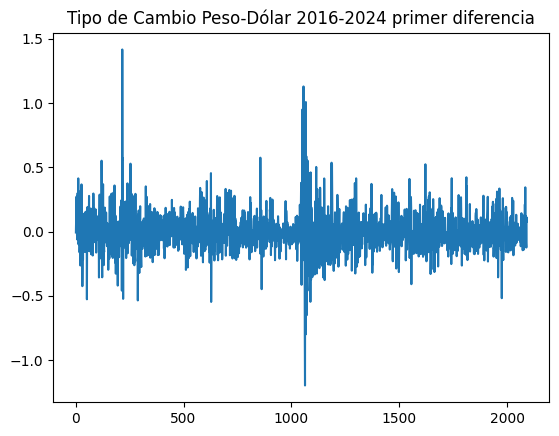

In [ ]:
# se encuentra la primer diferencia sin cambiar datos y se grafica
y_diff = close.diff().dropna()

y_diff.plot()
plt.title("Tipo de Cambio Peso-Dólar 2016-2024 primer diferencia")
plt.show() #esto es mas parecido a que no tiene tendencia

In [ ]:
pp_diff = PhillipsPerron(y_diff.dropna())
print(pp_diff.summary())

     Phillips-Perron Test (Z-tau)    
Test Statistic                -42.368
P-value                         0.000
Lags                               26
-------------------------------------

Trend: Constant
Critical Values: -3.43 (1%), -2.86 (5%), -2.57 (10%)
Null Hypothesis: The process contains a unit root.
Alternative Hypothesis: The process is weakly stationary.


In [ ]:
# volvemos a hacer dk fuller para ver si ya es estacionario o no

test1 = adfuller(y_diff.dropna())
print('ADF: %f' % test1[0])
print('P-Value ADF (serie diferenciada): %f'% test1[1])


# Aqui ya la serie no es estacionaria y lo comprueba la prueba de DK fuller y el p valor al ser meno al nivel de significancia (0.05) se rechaza la hipotesis nula
# Por lo que la prueba es estacionaria, esto quiere decir que la prueba no tiene tendencia

# Como solo se utilizo una diferencia en la prueba ARIMA el valor d ----> es 1
### ARIMA(PDQ) donde la D es 1

#Esto quiere decir que la serie es integrada de orden 1


ADF: -42.285136
P-Value ADF (serie diferenciada): 0.000000


In [ ]:
# Prueba Seasonality ------ estacionalidad

# Se utilizan dos test para la estacionalidad el de Hegy y el de Canova Hansen
#propiedad de observar patrones repetitivos y predecibles en las series
#Donde
#HO: existe estacionaliedad, existen patrones (deterministicos)
#H1: No existe estacionaliedad (patrones estocasticos)

#Importar librerias
from statsmodels.tsa.stattools import acf #Funcion de autocorelacion
valores = acf(close,nlags=252) #el n lags le voy a poner por los dias bursatiles ---->  esto no incluye dias festivos ni fines de semana
print(valores) #un lag es un resago de la variable dependiente


##### ejemplo yt = variable dependiente
#### Y(t-1) su primer resago

#Cuanta correlacion hay entre la variable dependiente y sus resagos


# aca se puede notar una caida controlada entre la variable y sus resagos



[1.         0.99308077 0.98520395 0.97733794 0.96950089 0.96214168
 0.95459197 0.947372   0.93978636 0.93139093 0.92289479 0.91455875
 0.90585521 0.89755206 0.88923522 0.88075139 0.87187275 0.86298359
 0.85450222 0.84621141 0.83772065 0.8296003  0.82181552 0.81381642
 0.80618572 0.79863191 0.7911041  0.78369082 0.77674691 0.76966417
 0.76253992 0.75582502 0.74889634 0.74224751 0.73586161 0.72975931
 0.72327943 0.71624145 0.70893003 0.7008986  0.69296665 0.68532515
 0.67782859 0.67104646 0.66461142 0.65837401 0.65204099 0.64550921
 0.63912613 0.63281257 0.62695725 0.62098534 0.61574736 0.61076276
 0.60607989 0.60188782 0.59792661 0.59396293 0.59019791 0.58631487
 0.58233032 0.57849991 0.5746254  0.57108524 0.56759199 0.56394646
 0.56075815 0.55728603 0.55374963 0.5503321  0.54646309 0.54250045
 0.53805215 0.53384965 0.52907419 0.52415825 0.51938407 0.51454053
 0.50946568 0.50434508 0.49943424 0.49445659 0.48921535 0.48425185
 0.47920098 0.47395173 0.46883113 0.46423407 0.45998307 0.4556

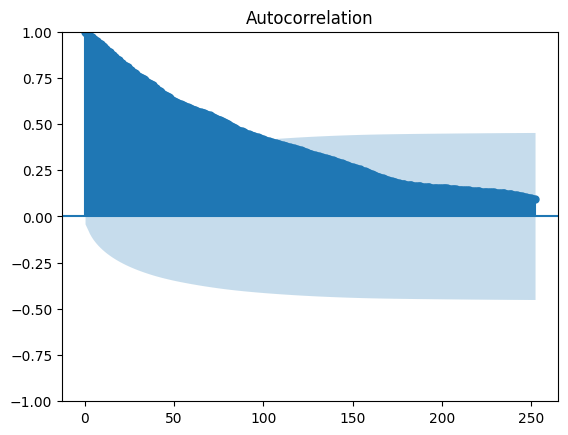

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf
#Ahora se grafican y se hace un test estadisticos
plot_acf(close,lags=252)
plt.show()

#La función de autocorrelación (ACF) muestra una caída lenta y gradual sin patrones repetitivos, lo que confirma la ausencia de
#estacionalidad en la serie. La expansión de la banda de confianza en rezagos mayores refleja una menor precisión en la estimación de la autocorrelación, resultado natural de contar con menos observaciones disponibles conforme aumenta el número de rezagos.



In [ ]:
# Esta es una serie no estacionaria y ademas estocasitca
# como no crecen los valores no existe una correlacion y pues es una serie de memoria larga
# Ademas la serie es de memoria larga ya que la serie se acerca a 0 lentamente por lo que caracteristicas del pasado siguen afectando al actual
# de acuerdo a nuestra investigaion al ser una serie de memoria larga tendriamos que modelar con ARFIMA en vez de con ARIMA pero por motivos del proyecto nos quedaremos con ARIMA

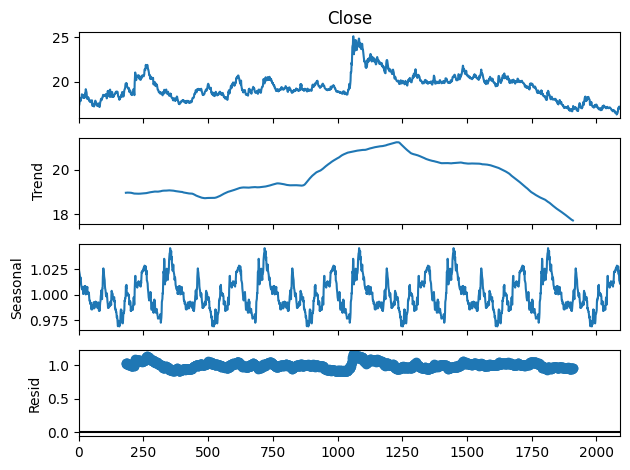

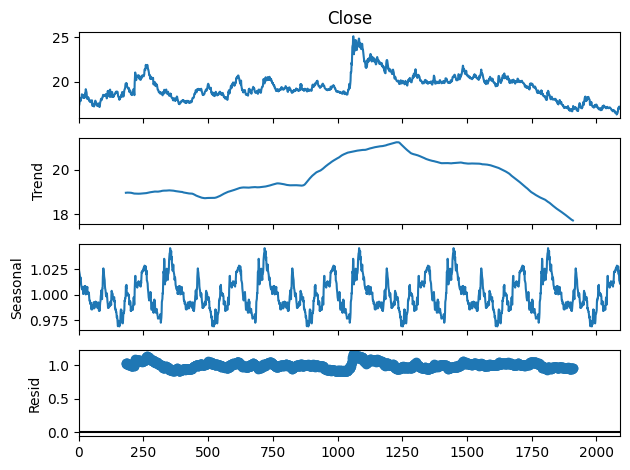

In [ ]:
#descomponiendo estacionalmente la serie
from statsmodels.tsa.seasonal import seasonal_decompose

descomposicion = seasonal_decompose(df["Close"],model='multiplicative',period=365)
descomposicion.plot()

In [ ]:
# En la primera serie es la serie original lo que es el tipo de cambio completo,
# el que dice Trend es el movimiento general de largo plazo sin el ruido diario. Se ve claramente cómo sube de 2016 a 2020 y luego baja al rededor de novimebre de la resesion
# en el de  Seasonal se ven los patrones repetitivos.lo que nos dice que la seasonality  entre 0.975 y 1.025 es muy pequeña
# Resid (residuos): lo que queda después de quitar tendencia y estacionalidad deberia de ser puro ruido, si se parece al seasonality es que no logoro separar correctamente la seasonality de los residuos
# lo que nos indica nuevamente que no existe estacionalidad (seasonality) por lo que es puro ruido si se pareciera a la tendencia es que no ha funcionado bien el residuo

In [ ]:
# Paso 3 Ahora vamos a hacer quiebres estructurales

# Aqui se identifican los shocks esto es un evento que hace que cambie la serie

#Shocks: Transitorios (luego del cambio la serie vuelve a su media inicial) convergente
# Shocks : Permanentes (Luego del cambio,la serie nunca vuelve a su media inicial (divergente))


#Para esto se utilizan los tests de #zivot y andrews que identifican los quiebres

from statsmodels.tsa.stattools import zivot_andrews,ZivotAndrewsUnitRoot



In [ ]:
### Como sabemos si esta serie tiene shocks transitorios o shocks permanentes
#sabes que hubo  permanentes con DK FULLER


# Calculamos el max lag para

# numero de datos  # El max lag, esta formula es la mas usada en econometria para series financieras
n = len(close.dropna()) # la n son el numero de variables
maxlag = int(12*(n/100)**0.25)
maxlag

25

In [ ]:
za = zivot_andrews(close,maxlag=maxlag)
print('\nZivot - Andrews',za[0])
print('P-Value',za[1])
print("Quiebre estructural",za[3])

## HO:existe quiebre estructural con shock permanente
## H1: Existe quiebre estructuralcon shocks transitorios


# Ya que el p valor es de 0.3496 este es mayor a 0.05 (el nivel de significancia ) por lo que no se rechaza la hipotesis nula

# esto quiere decir que existen quiebres estrucurales con shocks permanentes




Zivot - Andrews -4.004394457574508
P-Value 0.3496353021015291
Quiebre estructural 1


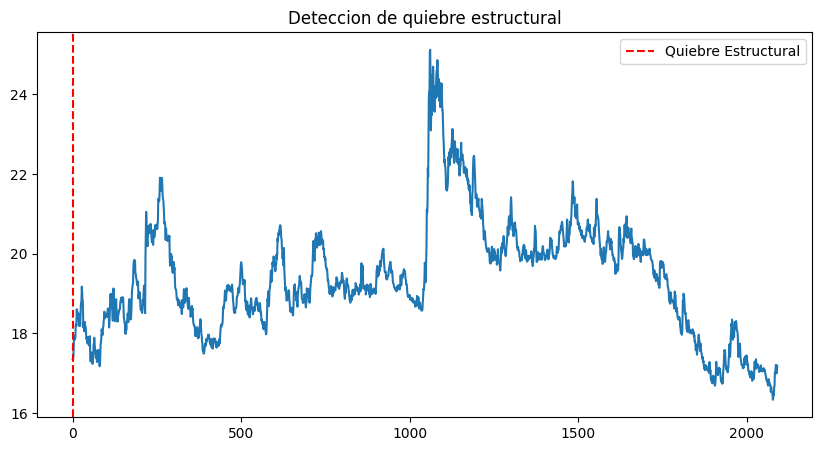

In [ ]:
quiebre = za[3]
fecha_quiebre=close.index[quiebre]
plt.figure(figsize=(10,5))
plt.plot(close)
plt.axvline(fecha_quiebre,color='red',linestyle="--",label="Quiebre Estructural")
plt.legend()
plt.title("Deteccion de quiebre estructural")
plt.show()

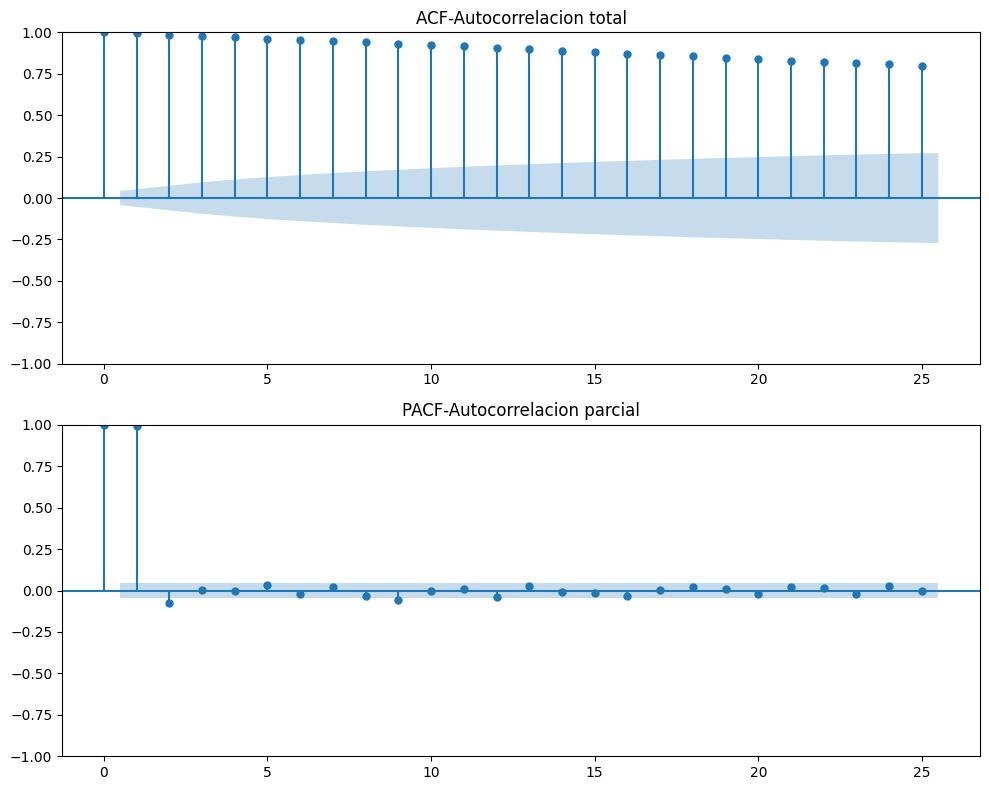

In [ ]:
#4) #Autocorrelacion (estructura arma Auto regresion y Moving Average )


from statsmodels.tsa.stattools import acf,pacf
from statsmodels.graphics.tsaplots import plot_acf,plot_pacf

fig,ax=plt.subplots(2,1,figsize=(10,8))
plot_acf(close,lags=25,ax=ax[0])
ax[0].set_title("ACF-Autocorrelacion total") #SIVE PARA ESTRUCTURA MX

plot_pacf(close,lags=25,ax=ax[1])
ax[1].set_title("PACF-Autocorrelacion parcial") #SIRVE PARA ESTRUCTURA AR


plt.tight_layout()
plt.show()

In [ ]:

# ACF -----> MA (Moving Average )-----> ya que todos los valores estan fuera del rango de seguridad la mejor opcion seria 0

# PACF ------> AR -------------> se le otorga al valor de 1 por que no bajan los indicadores





In [ ]:
# pt es el numero de rezagos autoregresivos AR (1)
# d: el orden de integracion de la serie I (1)
# q: el numero de medias moviles que se usaran en la serie: MA (moving average)(0)


In [ ]:
from statsmodels.tsa.arima.model import ARIMA

# Poner Date como índice primero
close2 = df.set_index('Date')['Close']
close2 = close2.asfreq('B')
close2 = close2.fillna(method='ffill')  # rellenar días feriados

modelo = ARIMA(close2, order=(1,1,0))
resultado = modelo.fit()

print(resultado.summary())

/tmp/ipykernel_5504/3206698238.py:6: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  close2 = close2.fillna(method='ffill')  # rellenar días feriados


                               SARIMAX Results                                
Dep. Variable:                  Close   No. Observations:                 2169
Model:                 ARIMA(1, 1, 0)   Log Likelihood                 966.135
Date:                Wed, 13 May 2026   AIC                          -1928.271
Time:                        02:27:49   BIC                          -1916.908
Sample:                    01-04-2016   HQIC                         -1924.115
                         - 04-25-2024                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0822      0.010      7.945      0.000       0.062       0.103
sigma2         0.0240      0.000     81.813      0.000       0.023       0.025
Ljung-Box (L1) (Q):                   0.01   Jarque-

In [ ]:
### LO QUE QUEREMOS ES QUE EL BIC SEA LO MAS BAJO POSIBLE
# Nuestro BIC = -1916.908 (negativo y bajo, señal de buen ajuste)

# Como el modelo no sabe que es estacional esto lo asume por eso se llama SARIMAX
# EL MODELO ESTIMADO ES ARIMA(1,1,0) para el tipo de cambio MXN/USD 2016-2024
# Se eligió por tener el menor BIC entre los modelos candidatos evaluados

# Los criterios de información
# AIC = Akaike = -1928.271 (entre más negativo mejor)
# BIC = Bayesiano = -1916.908 (entre más negativo mejor) ← criterio de selección
# HQIC = -1924.115 (entre más pequeño es mejor)

# Aquí nos fijamos en la significancia de las variables

# Como influye el pasado y la varianza del tipo de cambio

# EL VALOR z es el coeficiente entre el error estándar

# ar.L1 = 0.0822 → parámetro autorregresivo de orden 1
# Es el coeficiente del cambio actual del tipo de cambio con respecto al cambio anterior
# Está en positivo porque existe una ligera persistencia — si ayer el peso se depreció,
# hoy tiende a depreciarse un poco más
# Como el p-value es 0.000 < 0.05 se rechaza la nula, el rezago autorregresivo
# de primer orden SÍ influye en el tipo de cambio

# sigma2 = 0.0240 → varianza del error del modelo
# La parte no explicada del modelo tiene una varianza de 0.024 pesos²
# También es significativa (p=0.000)

### ABAJO se encuentran los indicadores de diagnóstico del modelo

# Ljung-Box p=0.91 > 0.05 → No hay autocorrelación en residuos
# Heteroskedasticidad p=0.00 → Varianza no constante, normal en series financieras
# Jarque-Bera p=0.00 → Residuos no normales, típico en tipo de cambio
# Kurtosis = 13.35 → Distribución con colas pesadas, existen muchos valores extremos
# Skew = 0.89 → Sesgo positivo, más depreciaciones que apreciaciones extremas

In [ ]:
# Ljung Box (autocorrelación)
## H0: Los residuos NO tienen autocorrelación
## HA: Los residuos SÍ tienen correlación
# p=0.91 > 0.05 → NO se rechaza la hipótesis nula
#  Los residuos no tienen autocorrelación, el modelo está bien especificado

# Heteroskedasticity (heterocedasticidad)
## H0: Existe homocedasticidad (varianzas iguales)
## H1: Existe heterocedasticidad (varianzas distintas)
# p=0.00 < 0.05 → Se rechaza la hipótesis nula
# Existe heterocedasticidad, pero en series financieras es completamente normal
# El tipo de cambio tiene períodos de alta y baja volatilidad (ej. pandemia 2020)

# Jarque-Bera (normalidad)
## H0: Existe normalidad en residuos
## HA: No existe normalidad en residuos
# p=0.00 < 0.05 → Se rechaza la hipótesis nula
#  No existe normalidad en residuos, puede ser una crítica al modelo
# Sin embargo es esperado en series de tipo de cambio con choques extremos

# Skew = 0.89 → sesgo positivo, significa que existen más depreciaciones
# extremas del peso que apreciaciones extremas

# Kurtosis = 13.35 → muy alta, la distribución es leptocúrtica
# significa que existen muchos outliers (valores extremos)
# Consistente con los choques de Trump 2016 y pandemia 2020

#### NOS QUEDAMOS CON ARIMA(1,1,0) POR TENER EL MENOR BIC = -1916.908

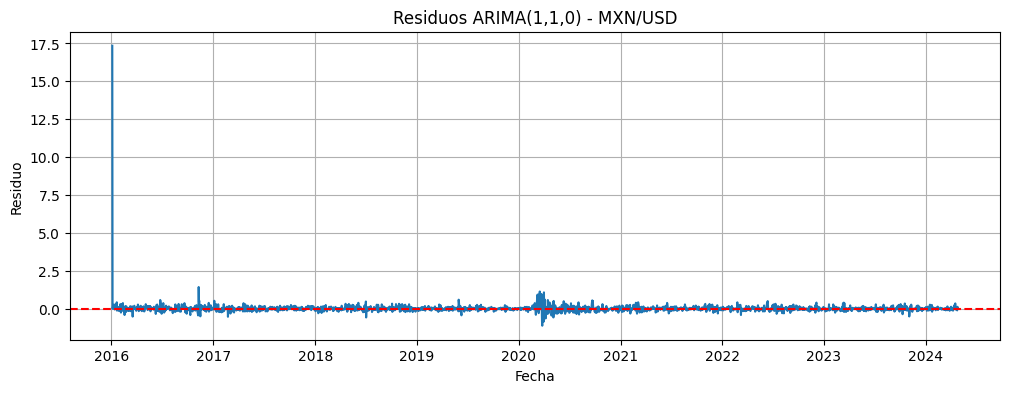

In [ ]:
residuos = resultado.resid

plt.figure(figsize=(12,4))
plt.plot(residuos)
plt.axhline(0, color='red', linestyle='--')
plt.title('Residuos ARIMA(1,1,0) - MXN/USD')
plt.xlabel('Fecha')
plt.ylabel('Residuo')
plt.grid(True)
plt.show()



#Los residuos del modelo ARIMA(1,1,0) se comportan como ruido blanco, oscilando alrededor de cero sin tendencia sistemática.
#Las únicas desviaciones significativas corresponden a los choques estructurales de noviembre 2016 (elección de Trump) y marzo 2020 (pandemia COVID-19),
#eventos de naturaleza exógena e impredecible que ningún modelo estadístico podría anticipar

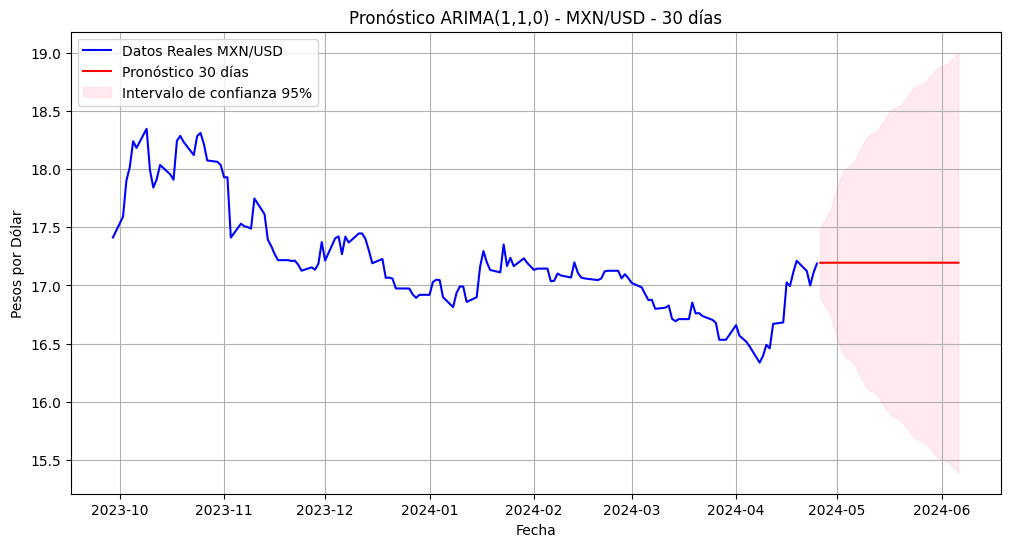

2024-04-26    17.194756
2024-04-29    17.195287
2024-04-30    17.195331
2024-05-01    17.195334
2024-05-02    17.195335
2024-05-03    17.195335
2024-05-06    17.195335
2024-05-07    17.195335
2024-05-08    17.195335
2024-05-09    17.195335
2024-05-10    17.195335
2024-05-13    17.195335
2024-05-14    17.195335
2024-05-15    17.195335
2024-05-16    17.195335
2024-05-17    17.195335
2024-05-20    17.195335
2024-05-21    17.195335
2024-05-22    17.195335
2024-05-23    17.195335
2024-05-24    17.195335
2024-05-27    17.195335
2024-05-28    17.195335
2024-05-29    17.195335
2024-05-30    17.195335
2024-05-31    17.195335
2024-06-03    17.195335
2024-06-04    17.195335
2024-06-05    17.195335
2024-06-06    17.195335
Freq: B, Name: predicted_mean, dtype: float64

--- Valores pronosticados 30 días ---
2024-04-26    17.194756
2024-04-29    17.195287
2024-04-30    17.195331
2024-05-01    17.195334
2024-05-02    17.195335
2024-05-03    17.195335
2024-05-06    17.195335
2024-05-07    17.195335
202

In [ ]:
# 30 predicciones

forecast_30 = resultado.get_forecast(steps=30)
pred_30 = forecast_30.predicted_mean
intervalo_30 = forecast_30.conf_int(alpha=0.05)

plt.figure(figsize=(12,6))
plt.plot(close2[-150:], label='Datos Reales MXN/USD', color='blue')
plt.plot(pred_30, label='Pronóstico 30 días', color='red')
plt.fill_between(intervalo_30.index,
                 intervalo_30.iloc[:,0],
                 intervalo_30.iloc[:,1],
                 color='pink', alpha=0.3,
                 label='Intervalo de confianza 95%')
plt.legend()
plt.title('Pronóstico ARIMA(1,1,0) - MXN/USD - 30 días')
plt.xlabel('Fecha')
plt.ylabel('Pesos por Dólar')
plt.grid(True)
plt.show()

print(pred_30)


print('\n--- Valores pronosticados 30 días ---')
print(pred_30.to_string())

print('\n--- Intervalo de confianza 95% ---')
print(intervalo_30.to_string())

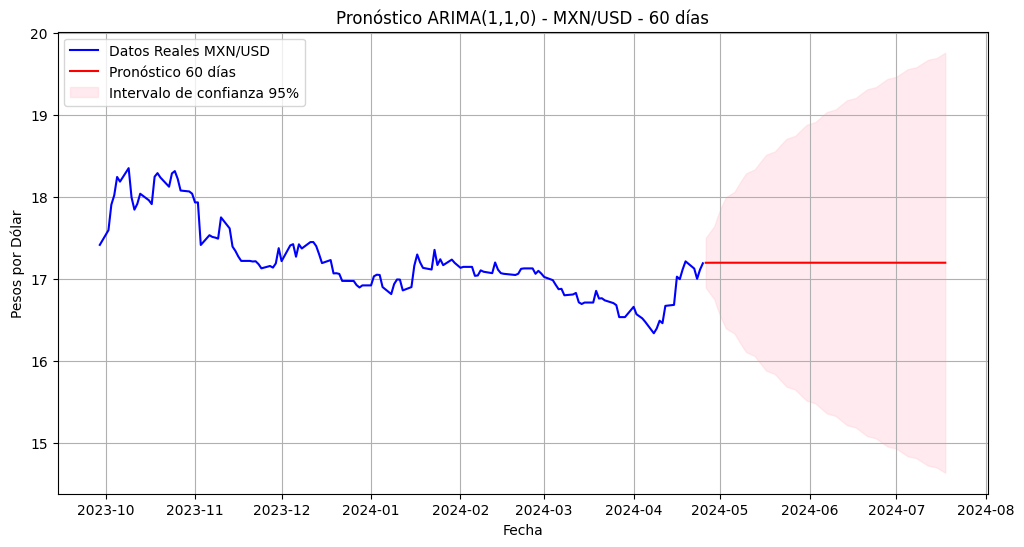


--- Valores pronosticados 60 días ---
2024-04-26    17.194756
2024-04-29    17.195287
2024-04-30    17.195331
2024-05-01    17.195334
2024-05-02    17.195335
2024-05-03    17.195335
2024-05-06    17.195335
2024-05-07    17.195335
2024-05-08    17.195335
2024-05-09    17.195335
2024-05-10    17.195335
2024-05-13    17.195335
2024-05-14    17.195335
2024-05-15    17.195335
2024-05-16    17.195335
2024-05-17    17.195335
2024-05-20    17.195335
2024-05-21    17.195335
2024-05-22    17.195335
2024-05-23    17.195335
2024-05-24    17.195335
2024-05-27    17.195335
2024-05-28    17.195335
2024-05-29    17.195335
2024-05-30    17.195335
2024-05-31    17.195335
2024-06-03    17.195335
2024-06-04    17.195335
2024-06-05    17.195335
2024-06-06    17.195335
2024-06-07    17.195335
2024-06-10    17.195335
2024-06-11    17.195335
2024-06-12    17.195335
2024-06-13    17.195335
2024-06-14    17.195335
2024-06-17    17.195335
2024-06-18    17.195335
2024-06-19    17.195335
2024-06-20    17.195335
2

In [ ]:
#Forecast 60 dias
forecast_60 = resultado.get_forecast(steps=60)
pred_60 = forecast_60.predicted_mean
intervalo_60 = forecast_60.conf_int(alpha=0.05)

plt.figure(figsize=(12,6))
plt.plot(close2[-150:], label='Datos Reales MXN/USD', color='blue')
plt.plot(pred_60, label='Pronóstico 60 días', color='red')
plt.fill_between(intervalo_60.index,
                 intervalo_60.iloc[:,0],
                 intervalo_60.iloc[:,1],
                 color='pink', alpha=0.3,
                 label='Intervalo de confianza 95%')
plt.legend()
plt.title('Pronóstico ARIMA(1,1,0) - MXN/USD - 60 días')
plt.xlabel('Fecha')
plt.ylabel('Pesos por Dólar')
plt.grid(True)
plt.show()

print('\n--- Valores pronosticados 60 días ---')
print(pred_60.to_string())

print('\n--- Intervalo de confianza 95% ---')
print(intervalo_60.to_string())

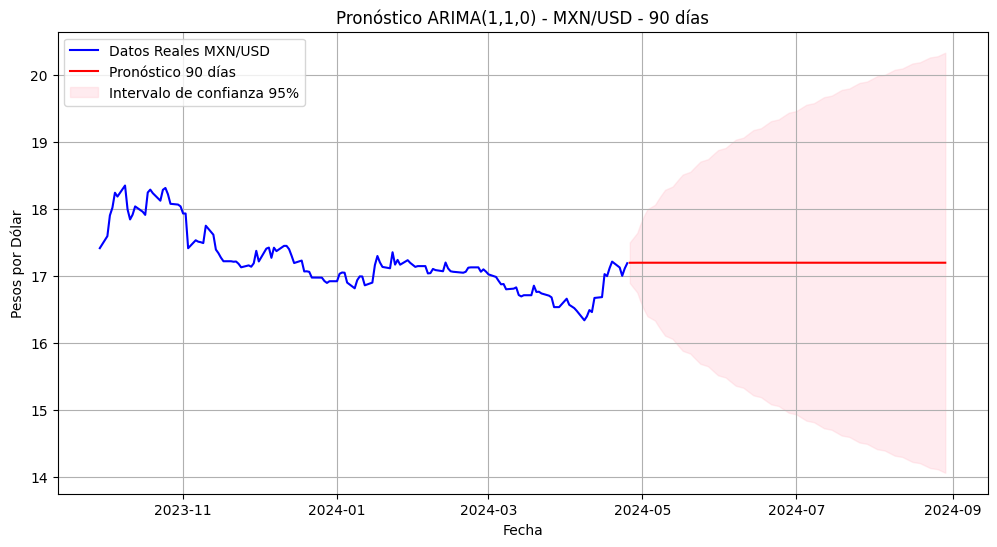


--- Valores pronosticados 90 días ---
2024-04-26    17.194756
2024-04-29    17.195287
2024-04-30    17.195331
2024-05-01    17.195334
2024-05-02    17.195335
2024-05-03    17.195335
2024-05-06    17.195335
2024-05-07    17.195335
2024-05-08    17.195335
2024-05-09    17.195335
2024-05-10    17.195335
2024-05-13    17.195335
2024-05-14    17.195335
2024-05-15    17.195335
2024-05-16    17.195335
2024-05-17    17.195335
2024-05-20    17.195335
2024-05-21    17.195335
2024-05-22    17.195335
2024-05-23    17.195335
2024-05-24    17.195335
2024-05-27    17.195335
2024-05-28    17.195335
2024-05-29    17.195335
2024-05-30    17.195335
2024-05-31    17.195335
2024-06-03    17.195335
2024-06-04    17.195335
2024-06-05    17.195335
2024-06-06    17.195335
2024-06-07    17.195335
2024-06-10    17.195335
2024-06-11    17.195335
2024-06-12    17.195335
2024-06-13    17.195335
2024-06-14    17.195335
2024-06-17    17.195335
2024-06-18    17.195335
2024-06-19    17.195335
2024-06-20    17.195335
2

In [ ]:
# Forecast 90 dias
forecast_90 = resultado.get_forecast(steps=90)
pred_90 = forecast_90.predicted_mean
intervalo_90 = forecast_90.conf_int(alpha=0.05)

plt.figure(figsize=(12,6))
plt.plot(close2[-150:], label='Datos Reales MXN/USD', color='blue')
plt.plot(pred_90, label='Pronóstico 90 días', color='red')
plt.fill_between(intervalo_90.index,
                 intervalo_90.iloc[:,0],
                 intervalo_90.iloc[:,1],
                 color='pink', alpha=0.3,
                 label='Intervalo de confianza 95%')
plt.legend()
plt.title('Pronóstico ARIMA(1,1,0) - MXN/USD - 90 días')
plt.xlabel('Fecha')
plt.ylabel('Pesos por Dólar')
plt.grid(True)
plt.show()

print('\n--- Valores pronosticados 90 días ---')
print(pred_90.to_string())

print('\n--- Intervalo de confianza 95% ---')
print(intervalo_90.to_string())

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error, r2_score
import numpy as np

y_real = close2.dropna()
y_fitted = resultado.fittedvalues

mse = mean_squared_error(y_real, y_fitted)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_real, y_fitted)
mape = mean_absolute_percentage_error(y_real, y_fitted)
r2 = r2_score(y_real, y_fitted)

print(f'MSE:  {mse:.4f}')
print(f'RMSE: {rmse:.4f}')
print(f'MAE:  {mae:.4f}')
print(f'MAPE: {mape:.4f}')
print(f'R²:   {r2:.4f}')

#El modelo ARIMA(1,1,0) tiene un desempeño muy bueno. El MAPE de 0.58% indica que el error promedio es menor al 1%,
#lo cual es excelente para una serie financiera. El R² de 0.92 confirma que el modelo captura bien la dinámica del tipo de cambio.


MSE:  0.1628
RMSE: 0.4035
MAE:  0.1126
MAPE: 0.0058
R²:   0.9232


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau



# Escalar datos entre 0 y 1
scaler = MinMaxScaler(feature_range=(0,1))
scaled_data = scaler.fit_transform(close2.values.reshape(-1,1))
print(f'Datos escalados: {scaled_data.shape}')

Datos escalados: (2169, 1)


In [ ]:
# Arquitectura Inicial - MXN/USD
# Generar el vector input (la arquitectura de la red neuronal tiene input para generar capas ocultas y ya despues el output)
# vector Vacío (vector input)

def secuencia(data, ventana=60): # tomamos los ultimos 60 dias habiles como historico representativo
    X, y = [], [] # x es el pasado de y
    for i in range(ventana, len(data)):
        X.append(data[i-ventana:i]) # aqui le estoy diciendo el pasado de los 60 periodos
        y.append(data[i,0])
    return np.array(X), np.array(y) # esto es para generar el vector x y y

lookback = 60 # cuantos periodos para atras se van a mover
X, y = secuencia(scaled_data, lookback)

# Division Train Test 80/20
train_size = int(0.8*len(X))
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

print(f'Train: {X_train.shape}')
print(f'Test: {X_test.shape}')



# estamos agarrando 60 dias por que es lo suficiente para predecir patrones recientes


Train: (1687, 60, 1)
Test: (422, 60, 1)


In [ ]:
# Arquitectura LSTM - MXN/USD

model = Sequential([
    # CAPA INPUT 2^7 = 128 unidades
    LSTM(128, return_sequences=True, input_shape=(X_train.shape[1], 1)),
    Dropout(0.2),  # desactiva 20% de neuronas para evitar overfitting
    # CAPA OCULTA 1
    LSTM(64, return_sequences=True),  # 2^6
    Dropout(0.2),
    # CAPA OCULTA 2
    LSTM(32),  # 2^5
    Dropout(0.2),
    # CAPA DENSA
    Dense(8, activation='relu'),
    # CAPA DE SALIDA
    Dense(1)  # variable continua (precio del tipo de cambio)
])

# COMPILAR
model.compile(optimizer='adam', loss='mean_squared_error')

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
### Early Stopping
###### Si yo tengo un diagrama de eje carteciano en error (y) y iteraciones en teoria el error debe de ir disminuyendo entonces esto sirve para encontrar la funcion minimizada para el mejor valor posible en base al earrly stopping

early_stop = EarlyStopping(monitor='val_loss',
                           patience = 50, #le pusimos paciencia de 50 para mejores resultados
                           restore_best_weights = True)
#Entrenamiento

history = model.fit(X_train,y_train,
                    epochs = 500,
                    batch_size=32,
                    validation_data = (X_test,y_test),
                    callbacks = [early_stop],
                    verbose=1)

Epoch 1/500
53/53 ━━━━━━━━━━━━━━━━━━━━ 19s 150ms/step - loss: 0.0161 - val_loss: 0.0018
Epoch 2/500
53/53 ━━━━━━━━━━━━━━━━━━━━ 7s 132ms/step - loss: 0.0045 - val_loss: 0.0018
Epoch 3/500
53/53 ━━━━━━━━━━━━━━━━━━━━ 8s 154ms/step - loss: 0.0042 - val_loss: 0.0018
Epoch 4/500
53/53 ━━━━━━━━━━━━━━━━━━━━ 7s 128ms/step - loss: 0.0038 - val_loss: 0.0015
Epoch 5/500
53/53 ━━━━━━━━━━━━━━━━━━━━ 8s 155ms/step - loss: 0.0032 - val_loss: 0.0011
Epoch 6/500
53/53 ━━━━━━━━━━━━━━━━━━━━ 7s 128ms/step - loss: 0.0031 - val_loss: 0.0010
Epoch 7/500
53/53 ━━━━━━━━━━━━━━━━━━━━ 10s 124ms/step - loss: 0.0029 - val_loss: 0.0011
Epoch 8/500
53/53 ━━━━━━━━━━━━━━━━━━━━ 11s 128ms/step - loss: 0.0027 - val_loss: 0.0019
Epoch 9/500
53/53 ━━━━━━━━━━━━━━━━━━━━ 8s 152ms/step - loss: 0.0026 - val_loss: 6.7296e-04
Epoch 10/500
53/53 ━━━━━━━━━━━━━━━━━━━━ 7s 123ms/step - loss: 0.0023 - val_loss: 7.1390e-04
Epoch 11/500
53/53 ━━━━━━━━━━━━━━━━━━━━ 8s 149ms/step - loss: 0.0021 - val_loss: 8.2543e-04
Epoch 12/500
53/53 ━━━━━━━

In [ ]:
# Prediccion y visualizacion y pred (y con acento circunflexo)

y_pred = model.predict(X_test)
y_pred = scaler.inverse_transform(y_pred.reshape(-1,1)) #esto es para decirle que se desescale
y_obs = scaler.inverse_transform(y_test.reshape(-1,1))

14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 68ms/step


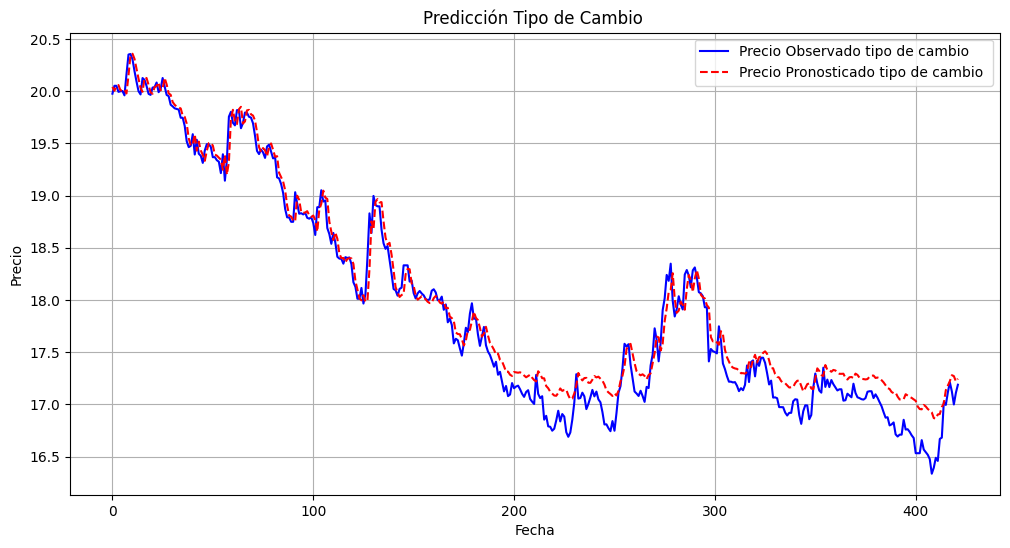

In [ ]:
#Visualizar para ver como se predice


plt.figure(figsize=(12,6))
plt.plot(y_obs,color="blue", label="Precio Observado tipo de cambio ")
plt.plot(y_pred,color="red", linestyle="--", label="Precio Pronosticado tipo de cambio ")
plt.title("Predicción Tipo de Cambio ")
plt.xlabel("Fecha")
plt.ylabel("Precio")
plt.legend()
plt.grid(True) #quiero que la cuadricula sea total en ambos vectores
plt.show()

### no esta mal mi prediccion pero no es exacto vamos a calcular las metricas

In [ ]:
# metricas

from sklearn.metrics import mean_absolute_error,mean_squared_error,mean_absolute_percentage_error,r2_score

mae = mean_absolute_error(y_obs,y_pred)
mape = mean_absolute_percentage_error(y_obs,y_pred)
rmse = np.sqrt(mean_squared_error(y_obs,y_pred))
r2 = r2_score(y_obs,y_pred)


print(f'MAE : {mae:.4f}')
print(f'MAPE : {mape:.4f}')
print(f'RMSE : {rmse:.4f}')
print(f'R2 : {r2:.4f}')

### el mape tiene que ser menor al 10 %
### un r2 del 84 por ciento vamos por buen camino


### tengo un margen de error de 11.15 dolares (mi rmse)

MAE : 0.1509
MAPE : 0.0086
RMSE : 0.1895
R2 : 0.9687


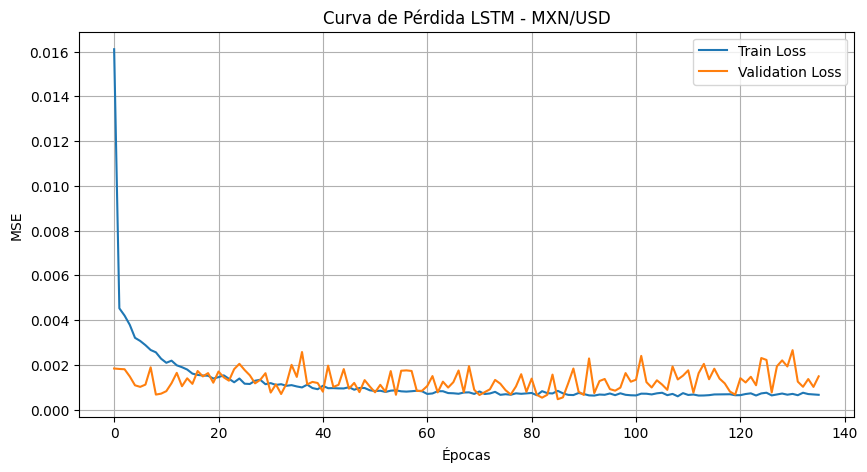

Épocas entrenadas: 136
Train Loss final: 0.000662
Validation Loss final: 0.001488
Diferencia Train-Val: 0.000826
 Sin overfitting significativo


In [ ]:
### CHECAR SI HAY OVERFITTING EN LA RED NEURONAL

plt.figure(figsize=(10,5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Curva de Pérdida LSTM - MXN/USD')
plt.xlabel('Épocas')
plt.ylabel('MSE')
plt.legend()
plt.grid(True)
plt.show()


# Comparación numérica Train vs Validation Loss
train_loss_final = history.history['loss'][-1]
val_loss_final = history.history['val_loss'][-1]
epocas_totales = len(history.history['loss'])

print(f'Épocas entrenadas: {epocas_totales}')
print(f'Train Loss final: {train_loss_final:.6f}')
print(f'Validation Loss final: {val_loss_final:.6f}')
print(f'Diferencia Train-Val: {abs(val_loss_final - train_loss_final):.6f}')

# Si la diferencia es menor a 0.001 -> no hay overfitting significativo
if abs(val_loss_final - train_loss_final) < 0.001:
    print(' Sin overfitting significativo')
else:
    print('Posible overfitting - revisar modelo')

--- Pronóstico LSTM 30 días ---
2024-04-26 → 17.2946 pesos por dólar
2024-04-29 → 17.3616 pesos por dólar
2024-04-30 → 17.4164 pesos por dólar
2024-05-01 → 17.4596 pesos por dólar
2024-05-02 → 17.4965 pesos por dólar
2024-05-03 → 17.5294 pesos por dólar
2024-05-06 → 17.5590 pesos por dólar
2024-05-07 → 17.5856 pesos por dólar
2024-05-08 → 17.6096 pesos por dólar
2024-05-09 → 17.6310 pesos por dólar
2024-05-10 → 17.6501 pesos por dólar
2024-05-13 → 17.6671 pesos por dólar
2024-05-14 → 17.6822 pesos por dólar
2024-05-15 → 17.6957 pesos por dólar
2024-05-16 → 17.7076 pesos por dólar
2024-05-17 → 17.7182 pesos por dólar
2024-05-20 → 17.7276 pesos por dólar
2024-05-21 → 17.7360 pesos por dólar
2024-05-22 → 17.7435 pesos por dólar
2024-05-23 → 17.7501 pesos por dólar
2024-05-24 → 17.7560 pesos por dólar
2024-05-27 → 17.7612 pesos por dólar
2024-05-28 → 17.7659 pesos por dólar
2024-05-29 → 17.7701 pesos por dólar
2024-05-30 → 17.7738 pesos por dólar
2024-05-31 → 17.7771 pesos por dólar
2024-0

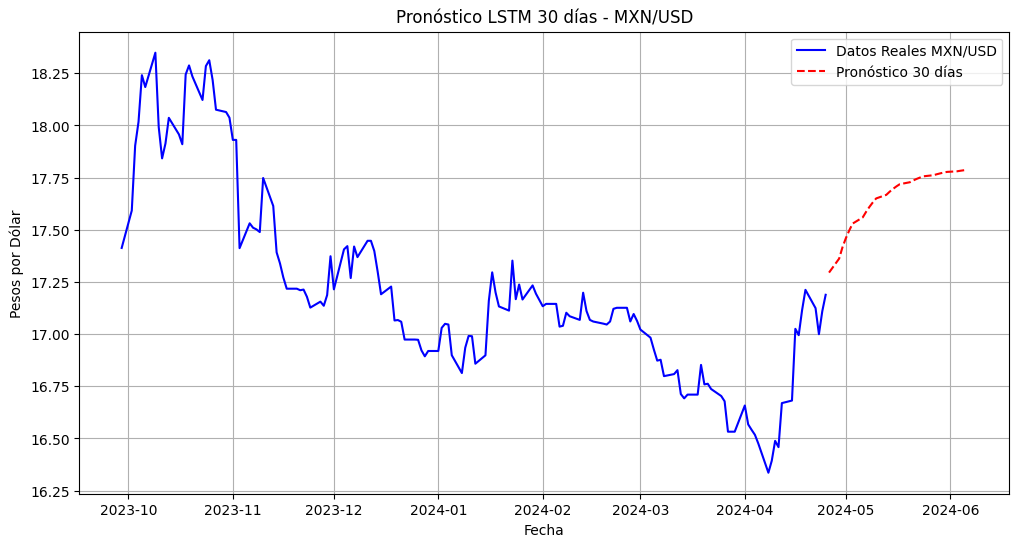

In [ ]:
# PRONÓSTICO 30 DÍAS - LSTM MXN/USD
future_30 = []
last_sequence = scaled_data[-lookback:].reshape(1, lookback, 1)

for _ in range(30):
    next_pred = model.predict(last_sequence, verbose=0)
    future_30.append(next_pred[0,0])
    last_sequence = np.append(last_sequence[:,1:,:], next_pred.reshape(1,1,1), axis=1)

future_30 = scaler.inverse_transform(np.array(future_30).reshape(-1,1))

# Fechas futuras
last_date = close2.index[-1]
fechas_futuras = pd.bdate_range(start=last_date, periods=31)[1:]

# Vector de días
print("--- Pronóstico LSTM 30 días ---")
for fecha, val in zip(fechas_futuras, future_30):
    print(f'{fecha.strftime("%Y-%m-%d")} → {val[0]:.4f} pesos por dólar')

# Gráfica
plt.figure(figsize=(12,6))
plt.plot(close2[-150:], color="blue", label="Datos Reales MXN/USD")
plt.plot(fechas_futuras, future_30, color="red", linestyle="--", label="Pronóstico 30 días")
plt.title("Pronóstico LSTM 30 días - MXN/USD")
plt.xlabel("Fecha")
plt.ylabel("Pesos por Dólar")
plt.legend()
plt.grid(True)
plt.show()

--- Pronóstico LSTM 60 días ---
2024-04-26 → 17.2946 pesos por dólar
2024-04-29 → 17.3616 pesos por dólar
2024-04-30 → 17.4164 pesos por dólar
2024-05-01 → 17.4596 pesos por dólar
2024-05-02 → 17.4965 pesos por dólar
2024-05-03 → 17.5294 pesos por dólar
2024-05-06 → 17.5590 pesos por dólar
2024-05-07 → 17.5856 pesos por dólar
2024-05-08 → 17.6096 pesos por dólar
2024-05-09 → 17.6310 pesos por dólar
2024-05-10 → 17.6501 pesos por dólar
2024-05-13 → 17.6671 pesos por dólar
2024-05-14 → 17.6822 pesos por dólar
2024-05-15 → 17.6957 pesos por dólar
2024-05-16 → 17.7076 pesos por dólar
2024-05-17 → 17.7182 pesos por dólar
2024-05-20 → 17.7276 pesos por dólar
2024-05-21 → 17.7360 pesos por dólar
2024-05-22 → 17.7435 pesos por dólar
2024-05-23 → 17.7501 pesos por dólar
2024-05-24 → 17.7560 pesos por dólar
2024-05-27 → 17.7612 pesos por dólar
2024-05-28 → 17.7659 pesos por dólar
2024-05-29 → 17.7701 pesos por dólar
2024-05-30 → 17.7738 pesos por dólar
2024-05-31 → 17.7771 pesos por dólar
2024-0

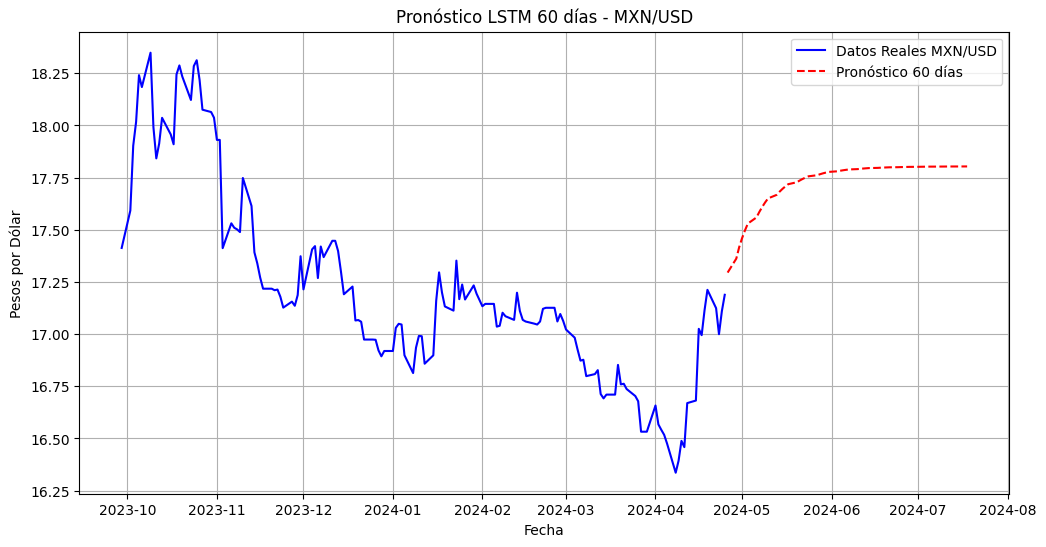

In [ ]:
# PRONÓSTICO 60 DÍAS - LSTM MXN/USD
future_60 = []
last_sequence = scaled_data[-lookback:].reshape(1, lookback, 1)

for _ in range(60):
    next_pred = model.predict(last_sequence, verbose=0)
    future_60.append(next_pred[0,0])
    last_sequence = np.append(last_sequence[:,1:,:], next_pred.reshape(1,1,1), axis=1)

future_60 = scaler.inverse_transform(np.array(future_60).reshape(-1,1))

# Fechas futuras
last_date = close2.index[-1]
fechas_futuras_60 = pd.bdate_range(start=last_date, periods=61)[1:]

# Vector de días
print("--- Pronóstico LSTM 60 días ---")
for fecha, val in zip(fechas_futuras_60, future_60):
    print(f'{fecha.strftime("%Y-%m-%d")} → {val[0]:.4f} pesos por dólar')

# Gráfica
plt.figure(figsize=(12,6))
plt.plot(close2[-150:], color="blue", label="Datos Reales MXN/USD")
plt.plot(fechas_futuras_60, future_60, color="red", linestyle="--", label="Pronóstico 60 días")
plt.title("Pronóstico LSTM 60 días - MXN/USD")
plt.xlabel("Fecha")
plt.ylabel("Pesos por Dólar")
plt.legend()
plt.grid(True)
plt.show()

--- Pronóstico LSTM 90 días ---
2024-04-26 → 17.2946 pesos por dólar
2024-04-29 → 17.3616 pesos por dólar
2024-04-30 → 17.4164 pesos por dólar
2024-05-01 → 17.4596 pesos por dólar
2024-05-02 → 17.4965 pesos por dólar
2024-05-03 → 17.5294 pesos por dólar
2024-05-06 → 17.5590 pesos por dólar
2024-05-07 → 17.5856 pesos por dólar
2024-05-08 → 17.6096 pesos por dólar
2024-05-09 → 17.6310 pesos por dólar
2024-05-10 → 17.6501 pesos por dólar
2024-05-13 → 17.6671 pesos por dólar
2024-05-14 → 17.6822 pesos por dólar
2024-05-15 → 17.6957 pesos por dólar
2024-05-16 → 17.7076 pesos por dólar
2024-05-17 → 17.7182 pesos por dólar
2024-05-20 → 17.7276 pesos por dólar
2024-05-21 → 17.7360 pesos por dólar
2024-05-22 → 17.7435 pesos por dólar
2024-05-23 → 17.7501 pesos por dólar
2024-05-24 → 17.7560 pesos por dólar
2024-05-27 → 17.7612 pesos por dólar
2024-05-28 → 17.7659 pesos por dólar
2024-05-29 → 17.7701 pesos por dólar
2024-05-30 → 17.7738 pesos por dólar
2024-05-31 → 17.7771 pesos por dólar
2024-0

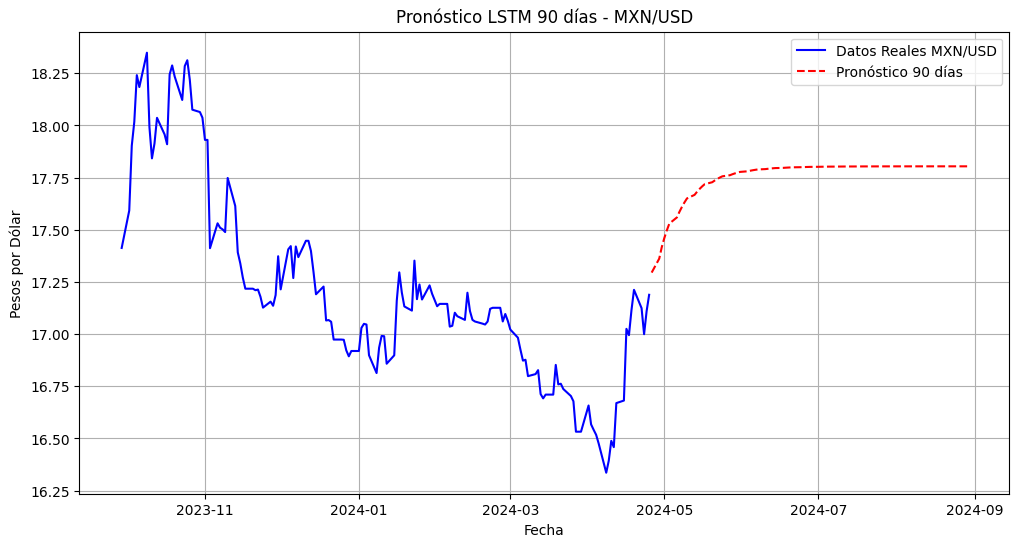

In [ ]:
# PRONÓSTICO 90 DÍAS - LSTM MXN/USD
future_90 = []
last_sequence = scaled_data[-lookback:].reshape(1, lookback, 1)

for _ in range(90):
    next_pred = model.predict(last_sequence, verbose=0)
    future_90.append(next_pred[0,0])
    last_sequence = np.append(last_sequence[:,1:,:], next_pred.reshape(1,1,1), axis=1)

future_90 = scaler.inverse_transform(np.array(future_90).reshape(-1,1))

# Fechas futuras
last_date = close2.index[-1]
fechas_futuras_90 = pd.bdate_range(start=last_date, periods=91)[1:]

# Vector de días
print("--- Pronóstico LSTM 90 días ---")
for fecha, val in zip(fechas_futuras_90, future_90):
    print(f'{fecha.strftime("%Y-%m-%d")} → {val[0]:.4f} pesos por dólar')

# Gráfica
plt.figure(figsize=(12,6))
plt.plot(close2[-150:], color="blue", label="Datos Reales MXN/USD")
plt.plot(fechas_futuras_90, future_90, color="red", linestyle="--", label="Pronóstico 90 días")
plt.title("Pronóstico LSTM 90 días - MXN/USD")
plt.xlabel("Fecha")
plt.ylabel("Pesos por Dólar")
plt.legend()
plt.grid(True)
plt.show()

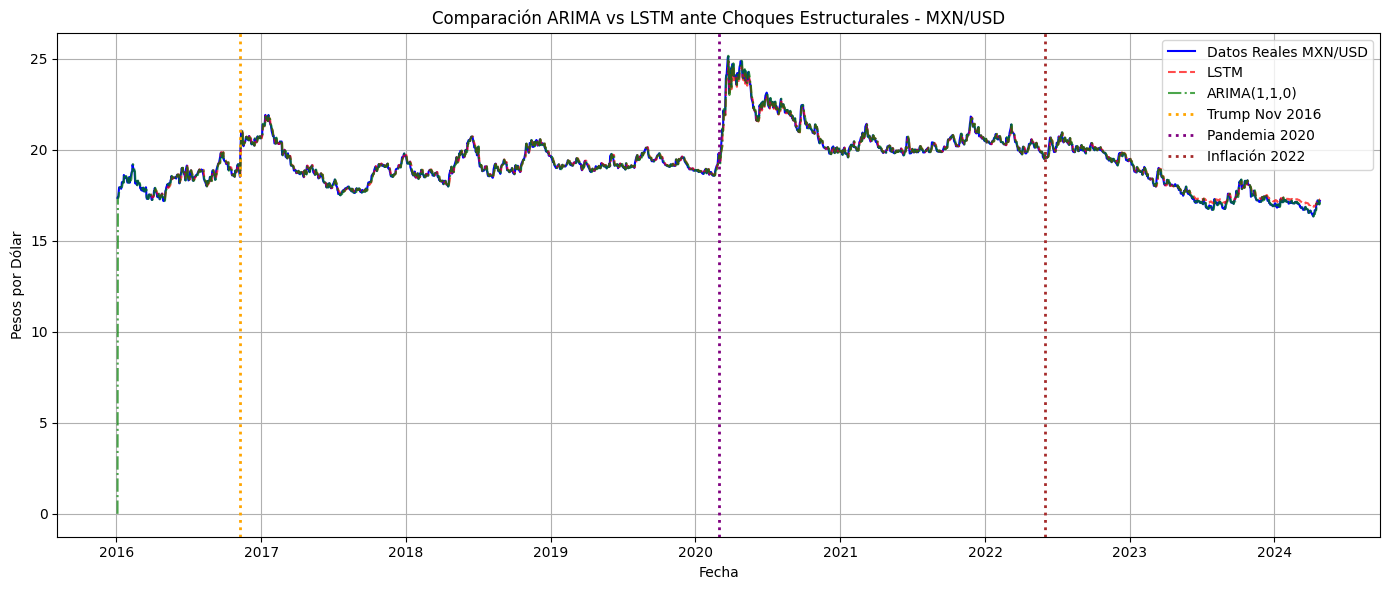

In [ ]:
# Predicciones ARIMA sobre toda la serie
arima_all = resultado.fittedvalues

# Predicciones LSTM sobre toda la serie
X_all, y_all = secuencia(scaled_data, lookback)
y_pred_all = model.predict(X_all, verbose=0)
y_pred_all = scaler.inverse_transform(y_pred_all)
fechas_all = close2.index[lookback:]

plt.figure(figsize=(14,6))
plt.plot(close2.index, close2.values, color='blue', label='Datos Reales MXN/USD', linewidth=1.5)
plt.plot(fechas_all, y_pred_all, color='red', linestyle='--', label='LSTM', linewidth=1.5, alpha=0.7)
plt.plot(arima_all.index, arima_all.values, color='green', linestyle='-.', label='ARIMA(1,1,0)', linewidth=1.5, alpha=0.7)

# Choques estructurales
plt.axvline(pd.Timestamp('2016-11-09'), color='orange', linestyle=':', linewidth=2, label='Trump Nov 2016')
plt.axvline(pd.Timestamp('2020-03-01'), color='purple', linestyle=':', linewidth=2, label='Pandemia 2020')
plt.axvline(pd.Timestamp('2022-06-01'), color='brown', linestyle=':', linewidth=2, label='Inflación 2022')

plt.title('Comparación ARIMA vs LSTM ante Choques Estructurales - MXN/USD')
plt.xlabel('Fecha')
plt.ylabel('Pesos por Dólar')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
# ANÁLISIS DE ERRORES ANTE CHOQUES ESTRUCTURALES

# Definir períodos de choque
periodos = {
    'Trump Nov 2016': ('2016-10-01', '2017-01-31'),
    'Pandemia 2020': ('2020-02-01', '2020-06-30'),
    'Inflación 2022': ('2022-01-01', '2022-12-31')
}

# Serie completa con predicciones
fechas_all = close2.index[lookback:]
reales = scaler.inverse_transform(y_all.reshape(-1,1))

print("=" * 65)
print(f"{'Período':<20} {'RMSE ARIMA':>15} {'RMSE LSTM':>15}")
print("=" * 65)

for nombre, (inicio, fin) in periodos.items():
    mask = (fechas_all >= inicio) & (fechas_all <= fin)

    if mask.sum() == 0:
        print(f"{nombre:<20} {'Sin datos':>15} {'Sin datos':>15}")
        continue

    real_periodo = reales[mask]
    lstm_periodo = y_pred_all[mask]
    arima_periodo = arima_all[inicio:fin].values[:len(real_periodo)]

    rmse_a = np.sqrt(mean_squared_error(real_periodo, arima_periodo))
    rmse_l = np.sqrt(mean_squared_error(real_periodo, lstm_periodo))

    print(f"{nombre:<20} {rmse_a:>15.4f} {rmse_l:>15.4f}")

print("=" * 65)

Período                   RMSE ARIMA       RMSE LSTM
Trump Nov 2016                0.2360          0.2408
Pandemia 2020                 0.3742          0.3845
Inflación 2022                0.1264          0.1288


In [ ]:
#El análisis comparativo ante choques estructurales revela que el modelo
#ARIMA(1,1,0) presenta menor error que el LSTM en los tres períodos
#críticos analizados. Durante la pandemia de 2020, ambos modelos
#registraron su mayor error (ARIMA: 0.3742, LSTM: 0.3845), confirmando
#que los choques extremos representan el mayor desafío predictivo.
#El ARIMA mostró ventaja en precisión ante eventos abruptos, mientras
#que el LSTM, a pesar de su mayor capacidad no lineal, no logró superar
#al modelo clásico en estos períodos de alta volatilidad.

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error, r2_score

mse_lstm = mean_squared_error(y_obs, y_pred)
rmse_lstm = np.sqrt(mse_lstm)
mae_lstm = mean_absolute_error(y_obs, y_pred)
mape_lstm = mean_absolute_percentage_error(y_obs, y_pred)
r2_lstm = r2_score(y_obs, y_pred)

print("=" * 55)
print(f"{'Métrica':<12} {'ARIMA(1,1,0)':>15} {'LSTM':>15}")
print("=" * 55)
print(f"{'MSE':<12} {0.1628:>15.4f} {mse_lstm:>15.4f}")
print(f"{'RMSE':<12} {0.4035:>15.4f} {rmse_lstm:>15.4f}")
print(f"{'MAE':<12} {0.1126:>15.4f} {mae_lstm:>15.4f}")
print(f"{'MAPE':<12} {0.0058:>15.4f} {mape_lstm:>15.4f}")
print(f"{'R²':<12} {0.9232:>15.4f} {r2_lstm:>15.4f}")
print("=" * 55)

Métrica         ARIMA(1,1,0)            LSTM
MSE                   0.1628          0.0359
RMSE                  0.4035          0.1895
MAE                   0.1126          0.1509
MAPE                  0.0058          0.0086
R²                    0.9232          0.9687


In [ ]:
#La tabla comparativa muestra resultados mixtos. El LSTM supera al
#ARIMA en MSE, RMSE y R² (0.9687 vs 0.9232), indicando mejor ajuste
#general. Sin embargo, el ARIMA presenta menor error absoluto y
#porcentual (MAE: 0.1126, MAPE: 0.58%), lo que lo hace más preciso
#en predicciones puntuales. Ante choques estructurales, el ARIMA
#mostró ventaja en los tres períodos críticos analizados.